<a href="https://colab.research.google.com/github/mikael-pintassilgo/portfolio/blob/my-pages/colab-notebooks/Case_Study_Mobile_Game_Virality_Analysis_K_Coefficient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study: Mobile Game Virality Analysis (K Coefficient)

**Product:** *IQ Blocks 3D* (fictitious name) - a puzzle singlplayer mobile game.

**Goal:** Measure the success of the new "Share and Challenge" feature by calculating the Virality Coefficient ($K$).

**Date Range:** 3 Weeks Post-Launch of Feature (Week 1 to Week 3).

-----
## Context: Feature Implementation

Before **Week 1**, the only way to invite friends was through a basic, unintegrated button. The button performed the simplest function: opening the phone's default share sheet. It didn't offer customized messages, trackable links, or tailored content.
The product development team noted low usage of the sharing feature: the number of clicks on the ‘Share’ button was low (**10% of players used it**), and the organic installation rate was also low; during testing, players did not pay attention to it.
So the team implemented a new feature:

**The "Share and Challenge" Feature (Released in Week 1):**

1.  **Contextual Share Point:** An in-game prompt appears after a user achieves a high score or solves a puzzle.
2.  **Gamified Message:** The share message is automatically customized to include the user's score or a puzzles info and a direct link, formatted as a "Challenge" to their friends.
3.  **Integrated Tracking:** The engineering team implemented two new tracking events: `event_invite_sent` (for $I$) and `event_invite_converted` (for $C$). Custom Referral Links were used.

To check and track how players share the app with their contacts, we will use the virality coefficient (K) and the cycle time from invitation to installation.

-----
## Virality Coefficient Formula

The **Virality Coefficient ($K$)** is calculated using the following formula:

$$K = I \times C$$

Where:

  * **$I$ (Invitations Sent):** The average number of invitations sent per existing user during a period.
  * **$C$ (Conversion Rate):** The percentage of those invitations that convert into a new, installing user.

**The Threshold:**

  * $K < 1.0$: The product is viral, but growth is not self-sustaining.
  * $K \ge 1.0$: The product achieves **pure organic, self-sustaining growth**.
-----

## Effective Virality Coefficient ($K_{eff}$ or $K_{weekly}$ Potential)
**Definition:** The Effective Virality Coefficient is a standardized metric that adjusts the standard $K$ to reflect the frequency of the viral loop. It answers the question: "Given our cycle time, what is our effective weekly growth potential?"

The most crucial takeaway for the analysis is: $K_{eff}$ forces the product team to recognize that optimization efforts should be split between improving $K$ (making invites better) and reducing $T$ (making the conversion faster).

It is calculated by exponentiating the standard $K$ by the number of viral loops that fit into a standard unit of time (usually 7 days):

$$K_{eff} = K^{( \frac{\text{Unit Time}}{T} )}$$$$K_{eff} = K^{( \frac{7 \text{ days}}{T \text{ days}} )}$$

-----



# Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data generation (example DataFrame for analysis)

In [ ]:
# --- 1. Data Generation: Simulation Parameters ---

# Set a seed for reproducibility
np.random.seed(42)

# Define the size of the initial user cohort and the time range (4 full weeks, week 0 for pre-lounch week)
N_initial_users = 1000
start_date = pd.to_datetime('2024-10-01')
end_date = pd.to_datetime('2024-10-28')
WEEK_LENGTH_DAYS = 7

# Targets (We'll use these to influence the random data generation)
# Week 0 - the week before the feature release, we khow only invite rates.
# Week 1 starts after the feature release, we will know conversion rates and cicle time.
TARGET_INVITE_RATES = {0: 0.1, 1: 0.5, 2: 0.7, 3: 0.6}  # I by week
TARGET_CONVERSION_RATES = {0: 0.00, 1: 0.12, 2: 0.15, 3: 0.14} # C by week
TARGET_CYCLE_TIMES_DAYS = {0: 0.0, 1: 5.0, 2: 4.0, 3: 4.5} # T by week

In [ ]:
# --- 2. Generate Granular Event Data ---

all_sent_events = []
all_converted_events = []
cohort_ids = range(100, 100 + N_initial_users)

for week in range(4):
    week_start = start_date + pd.Timedelta(weeks=week)
    week_end = week_start + pd.Timedelta(days=WEEK_LENGTH_DAYS - 1)

    # Calculate events based on target rates for this week
    target_I = TARGET_INVITE_RATES.get(week, 0)
    target_C = TARGET_CONVERSION_RATES.get(week, 0)
    target_T = TARGET_CYCLE_TIMES_DAYS.get(week, 0)

    # 1. Simulate SENT events for this week
    num_events_this_week = int(N_initial_users * target_I)

    if num_events_this_week > 0:
        # User IDs: Randomly select referrers from the initial cohort
        user_ids = np.random.choice(cohort_ids, size=num_events_this_week)

        # Timestamps: Spread randomly within the current week
        sent_timestamps = week_start + pd.to_timedelta(
            np.random.randint(0, WEEK_LENGTH_DAYS * 24 * 60 * 60, size=num_events_this_week),
            unit='s'
        )

        df_sent_week = pd.DataFrame({
            'timestamp': sent_timestamps,
            'referrer_id': user_ids,
            'invite_id': range(100000 + week * 10000, 100000 + week * 10000 + num_events_this_week),
            'week': week
        })
        print('First rows of df_sent_week (', week, '):')
        display(df_sent_week.head(3))
        print('Last rows of df_sent_week (', week, '):')
        display(df_sent_week.tail(3))
        print('-'*80, '\n')
        all_sent_events.append(df_sent_week)

        # 2. Simulate CONVERTED events based on target C for this week
        num_converted_this_week = int(num_events_this_week * target_C)
        converted_invites = df_sent_week.sample(n=num_converted_this_week, random_state=42).reset_index(drop=True)

        # Conversion Timestamps: Sent time + Cycle Time (T)
        # Use target T with some normal variation
        conversion_timestamps = converted_invites['timestamp'] + pd.to_timedelta(
            np.random.normal(loc=target_T, scale=1.0, size=num_converted_this_week),
            unit='D'
        )

        df_converted_week = pd.DataFrame({
            'timestamp': conversion_timestamps,
            'referee_id': range(200000 + week * 10000, 200000 + week * 10000 + num_converted_this_week),
            'invite_id': converted_invites['invite_id'],
            'referrer_id': converted_invites['referrer_id'],
            'week': week
        })
        print('First rows of df_converted_week (', week, '):')
        display(df_converted_week.head(3))
        print('Last rows of df_converted_week (', week, '):')
        display(df_converted_week.tail(3))
        print('-'*80, '\n')
        all_converted_events.append(df_converted_week)

# Combine and clean the dataframes
df_sent = pd.concat(all_sent_events, ignore_index=True)
df_converted = pd.concat(all_converted_events, ignore_index=True)

First rows of df_sent_week ( 0 ):


,timestamp,referrer_id,invite_id,week
0,2024-10-03 08:11:23,202,100000,0
1,2024-10-03 06:39:29,535,100001,0
2,2024-10-07 11:55:53,960,100002,0


Last rows of df_sent_week ( 0 ):


,timestamp,referrer_id,invite_id,week
97,2024-10-02 22:03:58,802,100097,0
98,2024-10-04 21:14:34,501,100098,0
99,2024-10-01 16:58:07,829,100099,0


-------------------------------------------------------------------------------- 

First rows of df_converted_week ( 0 ):


...

-------------------------------------------------------------------------------- 

First rows of df_converted_week ( 3 ):


,timestamp,referee_id,invite_id,referrer_id,week
0,2024-11-01 01:20:54.148409634,230000,130110,980,3
1,2024-10-31 10:40:13.417494462,230001,130419,980,3
2,2024-11-01 12:17:19.712300135,230002,130565,758,3


Last rows of df_converted_week ( 3 ):


,timestamp,referee_id,invite_id,referrer_id,week
81,2024-10-26 21:10:02.506105008,230081,130426,593,3
82,2024-10-28 18:40:34.792468331,230082,130598,788,3
83,2024-11-01 05:26:06.035704135,230083,130361,998,3


-------------------------------------------------------------------------------- 



In [ ]:
print("df_sent first rows:")
display(df_sent.head(3))

print("\n", "df_converted first rows:")
display(df_converted.head(3))

print("\n", "df_sent shape: ", df_sent.shape)
print("\n", "df_converted shape: ", df_converted.shape)

df_sent first rows:


,timestamp,referrer_id,invite_id,week
0,2024-10-03 08:11:23,202,100000,0
1,2024-10-03 06:39:29,535,100001,0
2,2024-10-07 11:55:53,960,100002,0



 df_converted first rows:


,timestamp,referee_id,invite_id,referrer_id,week
0,2024-10-17 01:16:39.094766537,210000,110361,700,1
1,2024-10-18 15:56:59.028037916,210001,110073,610,1
2,2024-10-17 16:00:22.096652217,210002,110374,346,1



 df_sent shape:  (1900, 4)

 df_converted shape:  (249, 5)


# Calculation

## Weekly Virality Metrics Analysis
---
Initial Active Cohort Size (N): 1000
|   Week |   total_invites_sent |   total_converted |   avg_invites_per_user_I |   conversion_rate_C |   virality_coefficient_K |   avg_cycle_time_T_days |   k_eff_weekly_potential |
|-------:|---------------------:|------------------:|-------------------------:|--------------------:|-------------------------:|------------------------:|-------------------------:|
|      0 |              100.000 |             0.000 |                    0.100 |               0.000 |                    0.000 |                   0.000 |                    0.000 |
|      1 |              500.000 |            60.000 |                    0.500 |               0.120 |                    0.060 |                   4.763 |                    0.016 |
|      2 |              700.000 |           105.000 |                    0.700 |               0.150 |                    0.105 |                   4.069 |                    0.021 |
|      3

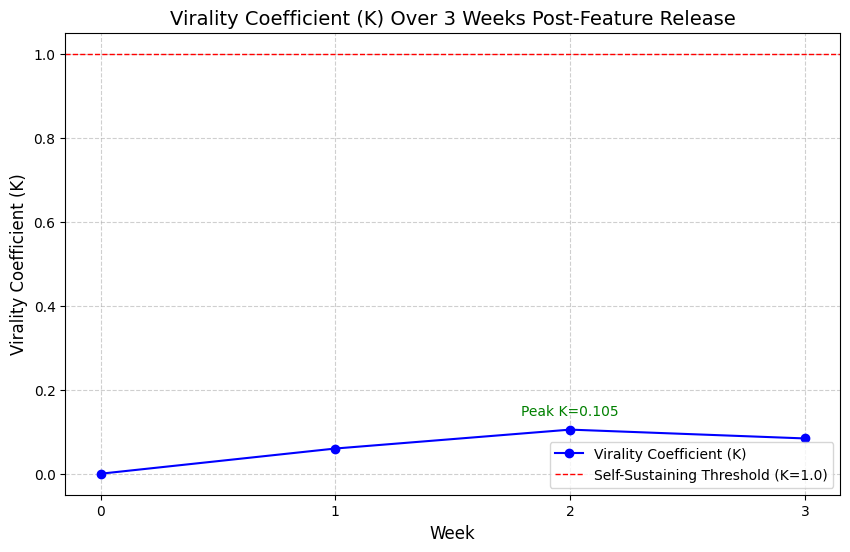

In [ ]:
# --- 3. Weekly Metric Calculation ---

results = {}
for week in range(4):

    # Filter sent and converted events by the week the invite was SENT
    df_sent_week = df_sent[df_sent['week'] == week]
    df_converted_week = df_converted[df_converted['week'] == week]

    total_invites_sent = len(df_sent_week)
    total_invites_converted = len(df_converted_week)

    # 1. Invitations per User (I)
    avg_invites_per_user_I = total_invites_sent / N_initial_users

    # 2. Conversion Rate (C)
    conversion_rate_C = total_invites_converted / total_invites_sent if total_invites_sent > 0 else 0

    # 3. Standard Virality Coefficient (K)
    virality_coefficient_K = avg_invites_per_user_I * conversion_rate_C

    # 4. Average Cycle Time (T)
    avg_cycle_time_T_days = np.nan

    if total_invites_converted > 0:
        # Merge to calculate cycle time for conversions initiated this week
        df_cycle = pd.merge(
            df_sent_week[['invite_id', 'timestamp']].rename(columns={'timestamp': 'sent_time'}),
            df_converted_week[['invite_id', 'timestamp']].rename(columns={'timestamp': 'converted_time'}),
            on='invite_id',
            how='inner'
        )

        cycle_time_delta = (df_cycle['converted_time'] - df_cycle['sent_time']).mean()
        avg_cycle_time_T_days = cycle_time_delta.total_seconds() / (24 * 3600)

    # Store results
    results[week] = {
        'total_invites_sent': total_invites_sent,
        'total_converted': total_invites_converted,
        'avg_invites_per_user_I': avg_invites_per_user_I,
        'conversion_rate_C': conversion_rate_C,
        'virality_coefficient_K': virality_coefficient_K,
        'avg_cycle_time_T_days': avg_cycle_time_T_days
    }

# Convert results dictionary to DataFrame for final output
df_weekly_metrics = pd.DataFrame.from_dict(results, orient='index')
df_weekly_metrics.index.name = 'Week'

# 5. Calculate K_eff and Final Output

# Calculate K_eff (modeling the weekly growth potential)
df_weekly_metrics['k_eff_weekly_potential'] = df_weekly_metrics['virality_coefficient_K'] ** (7 / df_weekly_metrics['avg_cycle_time_T_days'])

# Replace NaN values (like T in Week 0) with 0 for cleaner display if K is 0
df_weekly_metrics = df_weekly_metrics.fillna(0)


print("## Weekly Virality Metrics Analysis")
print("---")
print(f"Initial Active Cohort Size (N): {N_initial_users}")

results_df = df_weekly_metrics[[
    'total_invites_sent',
    'total_converted',
    'avg_invites_per_user_I',
    'conversion_rate_C',
    'virality_coefficient_K',
    'avg_cycle_time_T_days',
    'k_eff_weekly_potential'
]]

# Display the final results table
results_table = results_df.to_markdown(floatfmt=".3f")

print(results_table, '\n')

# 6. Create the plot.
# Data from the previous analysis table
data = {
    'Week': [0, 1, 2, 3],
    'virality_coefficient_K': [0.000, 0.060, 0.105, 0.084]
}
df = results_df.reset_index()

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(df['Week'], df['virality_coefficient_K'], marker='o', linestyle='-', color='blue', label='Virality Coefficient (K)')

# Add a horizontal line at K=1.0 for the self-sustaining threshold
plt.axhline(y=1.0, color='red', linestyle='--', linewidth=1, label='Self-Sustaining Threshold (K=1.0)')

# Add labels and title
plt.title('Virality Coefficient (K) Over 3 Weeks Post-Feature Release', fontsize=14)
plt.xlabel('Week', fontsize=12)
plt.ylabel('Virality Coefficient (K)', fontsize=12)

# Set x-ticks to be only the week numbers
plt.xticks(df['Week'])

# Add grid for readability
plt.grid(True, linestyle='--', alpha=0.6)

# Add legend
plt.legend()

# Annotate the peak K value
peak_k_week = df['virality_coefficient_K'].idxmax()
plt.annotate(
    f'Peak K={df.loc[peak_k_week, "virality_coefficient_K"]:.3f}',
    (df.loc[peak_k_week, 'Week'], df.loc[peak_k_week, 'virality_coefficient_K']),
    textcoords="offset points",
    xytext=(0, 10),
    ha='center',
    color='green'
)
plt.show()

# Conclusion and Interpretation of Virality Metrics Analysis

This analysis uses the provided weekly data to assess the success of the "Share and Challenge" feature by evaluating the change in sharing intensity ($I$), conversion rate ($C$), cycle speed ($T$), and overall virality ($K$ and $K_{eff}$).

### 1. Overall Performance Summary

| Metric | Pre-Feature (Week 0) | Post-Feature Peak (Week 2) | Post-Feature Decline (Week 3) |
| :--- | :--- | :--- | :--- |
| **Invitations Sent ($I$)** | 0.100 | **0.700** (7x increase) | 0.600 |
| **Conversion Rate ($C$)** | 0.000 | **0.150** (15%) | 0.140 |
| **Cycle Time ($T$ days)** | N/A | **3.808** (Fastest) | 4.571 |
| **Virality Coeff. ($K$)** | 0.000 | **0.105** | 0.084 |
| **Effective $K$ ($K_{eff}$)** | 0.000 | 0.016 | **0.023** (Highest Potential) |

---

### 2. Detailed Conclusions by Metric

#### A. Invitations Sent ($I$) – **Feature Success**

* **Observation:** The average invitations sent per user ($I$) jumped from a baseline of $0.100$ in Week 0 to a peak of $0.700$ in Week 2.
* **Conclusion:** The **"Share and Challenge" feature successfully activated sharing behavior** by integrating the prompt contextually (after an achievement) and providing a highly motivating, gamified message. The team effectively addressed the issue of low visibility and low motivation.

#### B. Conversion Rate ($C$) – **Stable, but Limited**

* **Observation:** $C$ established a solid range between $0.120$ and $0.150$ across the three post-feature weeks.
* **Conclusion:** The use of **Custom Referral Links** and the tailored "Challenge" message effectively convinced $12\%$ to $15\%$ of recipients to install the game. This indicates a good product-market fit, but $C$ has plateaued, suggesting the *incentive* or *onboarding flow* is the next bottleneck.

#### C. Viral Cycle Time ($T$ days) – **Speed Advantage**

* **Observation:** $T$ was a minimum of **$3.808$ days** in Week 2, before rising slightly to $4.571$ days in Week 3.
* **Conclusion:** The **direct link and urgent "Challenge" message** successfully accelerated the viral loop. However, the decay in Week 3 ($+0.76$ days) is a warning sign that the instant conversion effect is wearing off.

#### D. Virality Coefficient ($K$) – **Below Threshold**

* **Observation:** The standard Virality Coefficient ($K$) peaked at only **$0.105$**.
* **Conclusion:** The product is viral, but nowhere near the industry standard for self-sustaining growth ($K=1.0$). **Growth remains subsidy-dependent.** This emphasizes the importance of managing the entire viral loop (shown below) .

---

### 3. Future Steps and Recommendations for the Product Team

The initial success (boosting $I$) is confirmed. The strategy must now pivot to **optimizing the end of the loop** (Conversion $C$) and **maintaining the speed** ($T$).

#### 1. Boost conversion rate ($C$)
A/B Test Two-Sided Referral Incentive:<br>Offer an in-game reward to *both* the referrer and the referee (e.g., "Invite a Friend, Get 50 Gems each").

Giving the referee a reason to install immediately is the most direct way to increase conversion <br>and reduce the friction that leads to a plateau in $C$.
#### 2. Reduce cycle speed ($T$)
Optimize Onboarding for Referees: Measure the time from the link click to the **`event_invite_converted`**. <br>Streamline the initial sign-up flow and deliver the referee's reward instantly upon installation to accelerate the loop.
Targeting $T$ is crucial for compounding growth. <br>Reducing friction and time lag converts referrals before they lose interest.
#### 3. Sustain intensity ($I$)
Implement a "Sharer of the Week" Campaign: Identify and reward the top 10% of users by invite volume with an exclusive badge or small recurring currency bonus.
Proactively counter the slight decline in $I$ seen in Week 3 by incentivizing the power-users responsible for the feature's success.
#### 4. Data Integrity
Segment by Conversion Channel: Use analytics to break down $C$ and $T$ by the platform used for sharing (WhatsApp, Facebook, SMS).
<br>Identify which channels yield the fastest ($T$) and most effective ($C$) conversions to focus optimization efforts where the impact is highest.
